# MicroGrad

## Imports
---

In [1]:
import math
import matplotlib.pyplot as plt
import random

%matplotlib inline

## Value Class
---

In [2]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self.grad = 0.0

        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), "+")

        def _backward():
            self.grad += out.grad
            other.grad += out.grad

        out._backward = _backward
        return out

    def __radd__(self, other):  # other + self
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), "*")

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad

        out._backward = _backward
        return out

    def __rmul__(self, other):  # other * self
        return self * other

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):  # other - self
        return (-self) + other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting in / float powers"
        out = Value(self.data**other, (self,), f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad

        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * other**-1

    def exp(self):
        out = Value(math.exp(self.data), (self,), "exp")

        def _backward():
            self.grad += out.data * out.grad

        out._backward = _backward
        return out

    def tanh(self):
        x = self.data
        t = math.tanh(x)
        out = Value(t, (self,), "tanh")

        def _backward():
            self.grad += (1 - (t**2)) * out.grad

        out._backward = _backward
        return out

    def backward(self):
        topo = []
        visited = set()

        # post order traversal
        def build_topo(v):
            if v in visited:
                return
            visited.add(v)
            for child in v._prev:
                build_topo(child)
            topo.append(v)

        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

### Main idea behind backpropagation

Given a computational graph with final output (loss) $L$, our goal is to compute

$$
\frac{\partial L}{\partial a}
$$

for every node $a$ in the graph.

Let

$$
C(a)=\{c_1,c_2,\dots,c_n\}
$$

be the set of nodes computed directly from $a$, i.e.

$$
c_1=f_1(a,\ldots), \qquad
c_2=f_2(a,\ldots), \qquad
\ldots, \qquad
c_n=f_n(a,\ldots)
$$

Treating all other variables as fixed, the dependence of $L$ on $a$ is entirely through the variables $c_1,\ldots,c_n$. Hence we may write

$$
L = L(c_1,c_2,\dots,c_n,\ldots)
$$

where the "$\ldots$" denotes variables independent of $a$.

Applying the multivariable chain rule,

$$
\frac{\partial L}{\partial a}
=
\sum_{i=1}^{n}
\frac{\partial L}{\partial c_i}
\frac{\partial c_i}{\partial a}
$$

Thus, the gradient of a node is the **sum of all gradient contributions flowing through the nodes that directly depend on it**. This is why gradients must be accumulated during backpropagation.

## Visualising the Expression Graph
---

In [3]:
from graphviz import Digraph

In [4]:
def trace(root):
    # builds a set of all nodes and edges in the graph
    nodes, edges = set(), set()

    def build(v: Value):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)

    return nodes, edges

In [5]:
def draw_dot(root):
    dot = Digraph(format="svg", graph_attr={"rankdir": "LR"})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(
            name=uid,
            label=f"{{{n.label} | data {n.data} | grad {n.grad}}}",
            shape="record",
        )
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name=uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [6]:
a = Value(2.0, label="a")
b = Value(3.0, label="b")
c = a * b
c = c * c
c._prev, c._op

({Value(data=6.0, grad=0.0)}, '*')

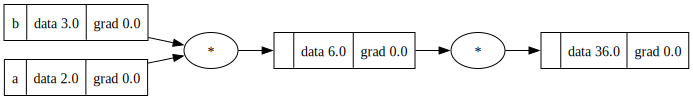

In [7]:
draw_dot(c)

In [8]:
class Module:
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0

    def parameters(self):
        return []


class Neuron(Module):
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # wx + b
        act = sum((wi * xi for wi, xi in zip(self.w, x)), self.b)
        return act.tanh()

    def parameters(self):
        return self.w + [self.b]


class Layer(Module):
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        return [n(x) for n in self.neurons]

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]


class MLP(Module):
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i + 1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [9]:
n = MLP(3, [4, 4, 1])

In [10]:
x = [2.0, 3.0, -1.0]
n(x)

[Value(data=-0.6459043489243145, grad=0.0)]

In [11]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0]  # desired targets

## Gradient Descent
---

In [12]:
# if the learning rate is too large it might not converge,
# as it might overshoot in case of large learning rate
# but if learning rate is too small it will converge too slow
learning_rate = 0.01
loss_history = []
for k in range(100):
    # forward pass
    ypred = [n(x)[0] for x in xs]
    loss = sum(((yout - ygt) ** 2 for ygt, yout in zip(ys, ypred)), Value(0.0))
    loss_history.append(loss.data)

    # backward pass
    n.zero_grad()
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -learning_rate * p.grad

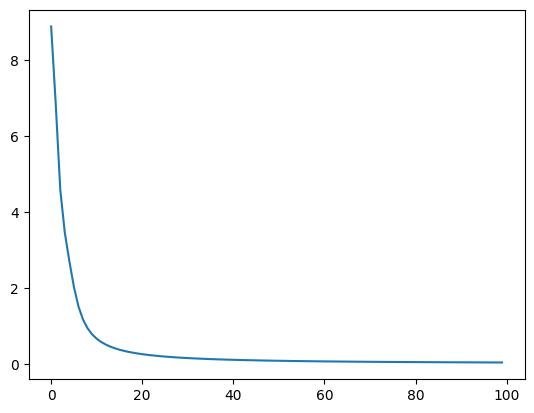

In [13]:
plt.plot(loss_history)